PLOT and ANALYSIS OF DATA: magnetic field and  muons data
Second PERIOD ANALYSIS

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import pytz


In [ ]:
vss2 = pd.read_csv('/second_period/vasouras.csv')
vss2['datetime'] = pd.to_datetime(vss2.Time)
#vss2.set_index(['datetime'], drop=True,inplace = True)

In [ ]:
import pandas as pd
import pytz

# Asegurar que la columna sea datetime
vss2['datetime'] = pd.to_datetime(vss2['datetime'])

# Localizar la zona horaria (suponiendo que los datos están en Paraguay)
paraguay_tz = pytz.timezone('America/Asuncion')
vss2['datetime'] = vss2['datetime'].dt.tz_localize(paraguay_tz)

# Convertir a UTC
vss2['datetime'] = vss2['datetime'].dt.tz_convert('UTC')

print(vss2)

                   Time  IntermagnetX  IntermagnetY  IntermagnetZ  \
0        9/16/2024 0:00         15927         -6779        -15443   
1        9/16/2024 0:01         15928         -6779        -15443   
2        9/16/2024 0:02         15928         -6779        -15443   
3        9/16/2024 0:03         15928         -6779        -15443   
4        9/16/2024 0:04         15929         -6779        -15443   
...                 ...           ...           ...           ...   
66175  10/31/2024 23:55         15920         -6771        -15459   
66176  10/31/2024 23:56         15921         -6771        -15459   
66177  10/31/2024 23:57         15921         -6771        -15459   
66178  10/31/2024 23:58         15921         -6771        -15459   
66179  10/31/2024 23:59         15921         -6771        -15459   

                       datetime  
0     2024-09-16 04:00:00+00:00  
1     2024-09-16 04:01:00+00:00  
2     2024-09-16 04:02:00+00:00  
3     2024-09-16 04:03:00+00:00  
4

In [ ]:
print(vss2['datetime'].dtype)

datetime64[ns, UTC]


In [ ]:
vss2.set_index(['datetime'], drop=True,inplace = True)

In [ ]:
vss2 = vss2.apply(pd.to_numeric, errors='coerce')



In [ ]:
vss2 = vss2.resample('5T').interpolate(method='linear')

C:\Users\Dell\AppData\Local\Temp\ipykernel_7860\1651173860.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  vss2 = vss2.resample('5T').interpolate(method='linear')


In [ ]:
flag_vss2 = np.logical_and(vss2.index >= '2024-10-10 09:20:00', vss2.index <= '2024-10-12 23:59:00')
vss2 = vss2[flag_vss2]

In [ ]:

vss2['pc_vss2'] = (vss2['IntermagnetX'] - vss2['IntermagnetX'].mean())/vss2['IntermagnetX'].mean() *100

MUONS

In [ ]:
df2 = pd.read_csv('/second_period/TMB3 & Vassouras Magnitude-data-Muons10m.csv')

In [ ]:
df2

,Time,TMB3
0,2024-10-10 09:20:00,28.1
1,2024-10-10 09:30:00,28.2
2,2024-10-10 09:40:00,28.3
3,2024-10-10 09:50:00,28.1
4,2024-10-10 10:00:00,28.1
...,...,...
672,2024-10-15 01:20:00,28.4
673,2024-10-15 01:30:00,28.0
674,2024-10-15 01:40:00,27.7
675,2024-10-15 01:50:00,27.8


In [ ]:
df2['datetime'] = pd.to_datetime(df2.Time)
df2.set_index(['datetime'], drop=True,inplace = True)

In [ ]:
df2 = df2.apply(pd.to_numeric, errors='coerce')
df2 = df2.resample('10T').interpolate(method='linear')


C:\Users\Dell\AppData\Local\Temp\ipykernel_7860\259649627.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df2 = df2.resample('10T').interpolate(method='linear')


In [ ]:
df2

,Time,TMB3
datetime,,
2024-10-10 09:20:00,NaN,28.1
2024-10-10 09:30:00,NaN,28.2
2024-10-10 09:40:00,NaN,28.3
2024-10-10 09:50:00,NaN,28.1
2024-10-10 10:00:00,NaN,28.1
...,...,...
2024-10-15 01:20:00,NaN,28.4
2024-10-15 01:30:00,NaN,28.0
2024-10-15 01:40:00,NaN,27.7


In [ ]:
flag_df2 = np.logical_and(df2.index >= '2024-10-10 09:20:00', df2.index <= '2024-10-12 23:59:00')
df2 = df2[flag_df2]

In [ ]:
df2['pc_df2'] = (df2['TMB3'] - df2['TMB3'].mean())/df2['TMB3'].mean() *100

In [ ]:
import matplotlib.dates as mdates


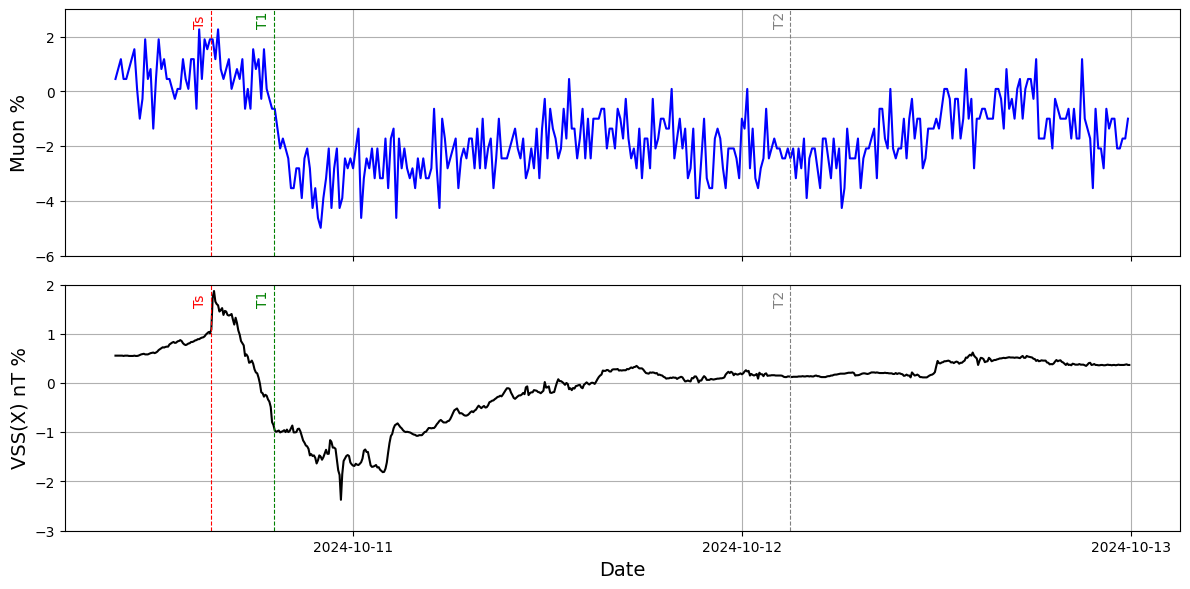

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


T_s = pd.Timestamp('2024-10-10 15:14:00')
T1 = pd.Timestamp('2024-10-10 19:08:00')
T2 = pd.Timestamp('2024-10-12 03:00:00')


fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 6))


ax1.plot(df2.index, df2['pc_df2'] , color='blue')
ax1.set_ylabel('Muon %',  fontsize=14)
ax1.set_ylim(-6,3)
ax1.grid(True)

ax2.plot(vss2.index, vss2['pc_vss2'], color='black')
ax2.set_ylabel('VSS(X) nT %', fontsize=14)
ax2.set_xlabel('Date', fontsize=14)
ax2.set_ylim(-3, 2)
ax2.grid(True)

for ax in [ax1, ax2]:
    Ts_ajustado = T_s
    ax.axvline(T_s, color='red', linestyle='--', label='Ts', linewidth=0.8)
    ax.text(Ts_ajustado, ax.get_ylim()[1] * 0.80, 'Ts', color='red', ha='center', fontsize=10, rotation=90)

    T1_ajustado = T1
    ax.axvline(T1, color='green', linestyle='--', label='T1', linewidth=0.8)
    ax.text(T1_ajustado, ax.get_ylim()[1] * 0.80, 'T1', color='green', ha='center', fontsize=10, rotation=90)

    T2_ajustado = T2
    ax.axvline(T2, color='gray', linestyle='--', label='T2', linewidth=0.8)
    ax.text(T2_ajustado, ax.get_ylim()[1] * 0.80, 'T2', color='gray', ha='center', fontsize=10, rotation=90)

ax2.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))


plt.savefig('vss_muons_second_period_new.png', dpi=300)
plt.tight_layout()
plt.show()


In [ ]:
SECOND PERIOD ANALYSIS

In [ ]:
df = pd.read_csv('second_period/TMB3 & Vassouras Magnitude-data-Muons_2024.csv')

In [ ]:
df['datetime'] = pd.to_datetime(df['Time'], errors='coerce')

In [ ]:
import pandas as pd
import pytz


df['datetime'] = pd.to_datetime(df['datetime'])

paraguay_tz3 = pytz.timezone('America/Asuncion')
df['datetime'] = df['datetime'].dt.tz_localize(paraguay_tz1)

df['datetime'] = df['datetime'].dt.tz_convert('UTC')

print(df)

                    Time  TMB3                  datetime
0    2024-05-09 11:05:00  30.7 2024-05-09 15:05:00+00:00
1    2024-05-09 11:30:00  31.6 2024-05-09 15:30:00+00:00
2    2024-05-09 11:55:00  31.6 2024-05-09 15:55:00+00:00
3    2024-05-09 12:20:00  31.3 2024-05-09 16:20:00+00:00
4    2024-05-09 12:45:00  31.4 2024-05-09 16:45:00+00:00
..                   ...   ...                       ...
256  2024-05-13 21:45:00  31.1 2024-05-14 01:45:00+00:00
257  2024-05-13 22:10:00  30.9 2024-05-14 02:10:00+00:00
258  2024-05-13 22:35:00  31.1 2024-05-14 02:35:00+00:00
259  2024-05-13 23:00:00  31.0 2024-05-14 03:00:00+00:00
260  2024-05-13 23:25:00  30.6 2024-05-14 03:25:00+00:00

[261 rows x 3 columns]


In [ ]:
df = df.apply(pd.to_numeric, errors='coerce')

In [ ]:
df.set_index('datetime', inplace=True)

In [ ]:
flag_df = np.logical_and(df.index >= '2024-05-10 00:00:00', df.index <= '2024-05-13 23:59:00')
df = df[flag_df]

In [ ]:
df['pc_df'] = (df['TMB3'] - df['TMB3'].mean())/df['TMB3'].mean() *100

C:\Users\Dell\AppData\Local\Temp\ipykernel_7860\3890481568.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pc_df'] = (df['TMB3'] - df['TMB3'].mean())/df['TMB3'].mean() *100


In [ ]:
vss = pd.read_csv('second_period/vasouras.csv')
vss['datetime'] = pd.to_datetime(vss.Time)

In [ ]:
import pandas as pd
import pytz

vss['datetime'] = pd.to_datetime(vss['datetime'])

paraguay_tz1 = pytz.timezone('America/Asuncion')
vss['datetime'] = vss['datetime'].dt.tz_localize(paraguay_tz1)

vss['datetime'] = vss['datetime'].dt.tz_convert('UTC')

print(vss)

                  Time  IntermagnetX  IntermagnetY  IntermagnetZ  \
0        5/6/2024 0:00         15955         -6789        -15404   
1        5/6/2024 0:01         15955         -6789        -15404   
2        5/6/2024 0:02         15954         -6789        -15404   
3        5/6/2024 0:03         15954         -6789        -15404   
4        5/6/2024 0:04         15954         -6789        -15404   
...                ...           ...           ...           ...   
71995  6/24/2024 23:55         15983         -6785        -15416   
71996  6/24/2024 23:56         15983         -6785        -15417   
71997  6/24/2024 23:57         15983         -6785        -15416   
71998  6/24/2024 23:58         15984         -6785        -15416   
71999  6/24/2024 23:59         15983         -6785        -15416   

                       datetime  
0     2024-05-06 04:00:00+00:00  
1     2024-05-06 04:01:00+00:00  
2     2024-05-06 04:02:00+00:00  
3     2024-05-06 04:03:00+00:00  
4     2024-05

In [ ]:
vss.set_index(['datetime'], drop=True,inplace = True)

In [ ]:
flag_vss2= np.logical_and(vss.index >= '2024-05-10 00:00:00', vss.index <= '2024-05-13 23:59:00')
vss = vss[flag_vss2]


In [ ]:
vss = vss.apply(pd.to_numeric, errors='coerce')
vss = vss.resample('15T').interpolate(method='linear')

C:\Users\Dell\AppData\Local\Temp\ipykernel_7860\2525189218.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  vss = vss.resample('15T').interpolate(method='linear')


In [ ]:
vss['pc_vss'] = (vss['IntermagnetX'] - vss['IntermagnetX'].mean())/vss['IntermagnetX'].mean() *100

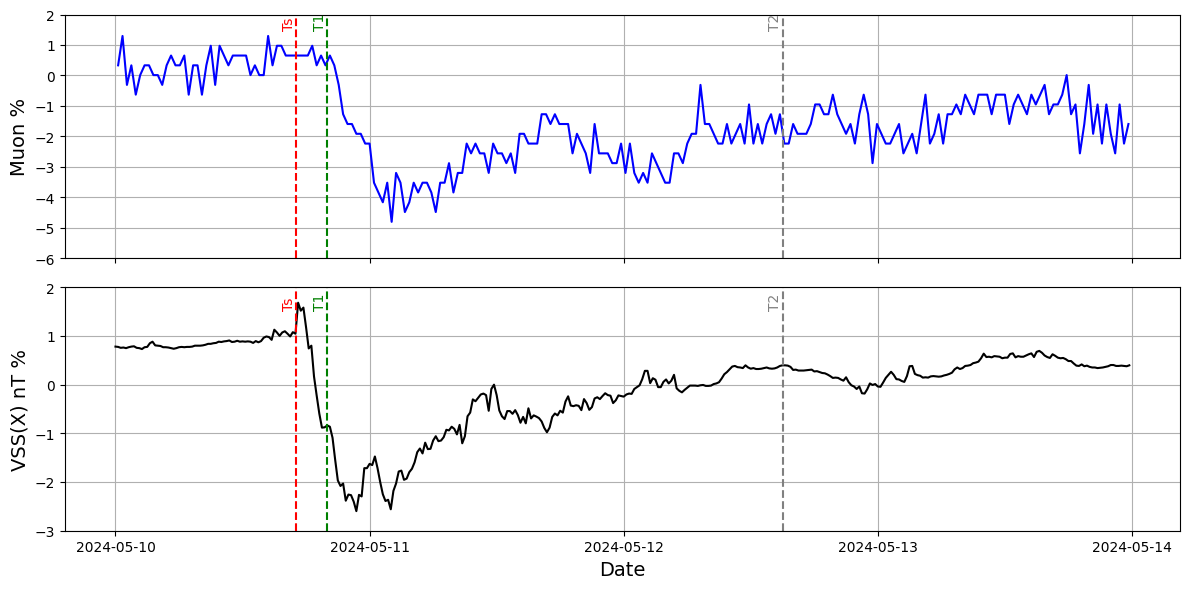

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


T_s = pd.Timestamp('2024-05-10 17:05:00')
T1 = pd.Timestamp('2024-05-10 20:00:00')
T2 = pd.Timestamp('2024-05-12 15:00:00')

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 6))

ax1.plot(df.index, df['pc_df'] , color='blue')
ax1.set_ylabel('Muon %',  fontsize=14)
ax1.set_ylim(-6,2)
ax1.grid(True)

ax2.plot(vss.index, vss['pc_vss'], color='black')
ax2.set_ylabel('VSS(X) nT %', fontsize=14)
ax2.set_xlabel('Date', fontsize=14)
ax2.set_ylim(-3, 2)
ax2.grid(True)

for ax in [ax1, ax2]:
    Ts_ajustado = T_s
    ax.axvline(T_s, color='red', linestyle='--', label='Ts')
    ax.text(Ts_ajustado, ax.get_ylim()[1] * 0.80, 'Ts', color='red', ha='center', fontsize=10, rotation=90)

    T1_ajustado = T1 
    ax.axvline(T1, color='green', linestyle='--', label='T1')
    ax.text(T1_ajustado, ax.get_ylim()[1] * 0.80, 'T1', color='green', ha='center', fontsize=10, rotation=90)

    T2_ajustado = T2 
    ax.axvline(T2, color='gray', linestyle='--', label='T2')
    ax.text(T2_ajustado, ax.get_ylim()[1] * 0.80, 'T2', color='gray', ha='center', fontsize=10, rotation=90)

ax2.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))


plt.savefig('vss_muons_first_period_new.png', dpi=300)
plt.tight_layout()
plt.show()